In [1]:
# Importing required libraries and functions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sampling_strategies import random_sampling, margin_sampling, full_model

In [2]:
# Importing preprocessed features (obtained as shown in the "feature_extraction.ipynb" notebook)
df = pd.read_csv("preprocessed_features_bottles.csv")  # bottle_mixed

In [3]:
# Setting hyperparameters for the sampling strategies
REPS = 50  # number of replications with different seeds
START = 30  # number of labeled examples used to initialize the regularized logistic regression model
EACH_ROUND = 1  # number of images to be labeled at each step (one-by-one active learning)
ITERS = 100  # number of learning steps (budget)

In [4]:
# Running the three strategies: random sampling, margin-based active learning and the model using all the labeled examples
# The same seed is used by the three strategies at each step to ensure the same test set is used for evaluation
rnd = random_sampling(data=df, initial_size=START, reps=REPS, iters=ITERS, num_instances_to_label=EACH_ROUND)
unc = margin_sampling(data=df, initial_size=START, reps=REPS, iters=ITERS, num_instances_to_label=EACH_ROUND)
full = full_model(data=df, initial_size=START, reps=REPS)

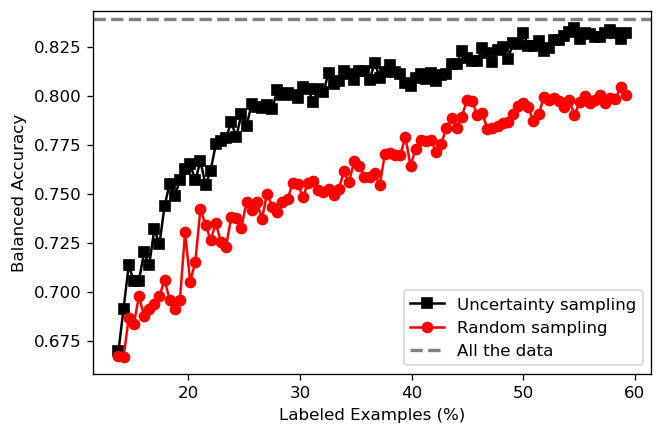

In [5]:
percentages = np.arange(30, 130)/218*100
plt.figure(dpi=120)
plt.plot(percentages, np.mean(unc, axis=0), label="Uncertainty sampling", c="k", marker="s")
plt.plot(percentages, np.mean(rnd, axis=0), label="Random sampling", c="r", marker="o")
plt.axhline(y=np.mean(full), label="All the data", c="grey", ls="--", lw=2)
plt.xlabel("Labeled Examples (%)")
plt.ylabel("Balanced Accuracy")
plt.legend(loc="lower right")